In [6]:
import torch 

from pathlib import Path  

ckpt_dir = Path("/Users/hawardizayee/Desktop/AMI/eb_jepa_data/checkpoints/image_jepa/")

In [ ]:
embeding_history = torch.load(ckpt_dir / "dev_2026-08-23_15-32" / "resnet_vicreg_proj_bs256_ep300_ph1024_po1024_std1.0_cov100.0_seed42" / "embedding_history.pt")
latest_model = torch.load(ckpt_dir / "dev_2026-08-23_15-32" / "resnet_vicreg_proj_bs256_ep300_ph1024_po1024_std1.0_cov100.0_seed42" / "latest.pth.tar",map_location="cpu")

In [16]:
embeding_history["z1_history"][-1].std(dim=0).mean()

tensor(0.9430)

In [21]:
embeding_history["z1_history"][-1][:32, :32].shape

torch.Size([32, 32])

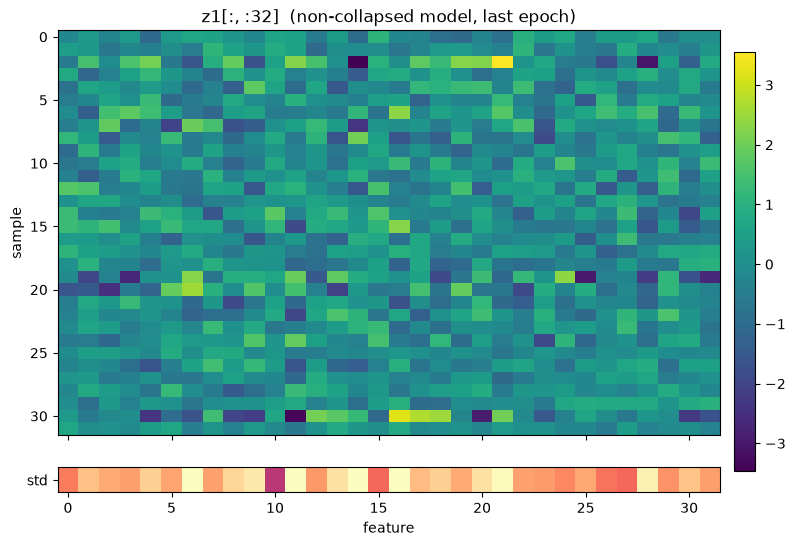

In [22]:

import numpy as np
import matplotlib.pyplot as plt
# pick which epoch's monitor batch to inspect (-1 = last / most collapsed)
z = embeding_history["z1_history"][-1][:32, :32].numpy()   # (samples, first 32 features)
std = z.std(axis=0)                   # per-feature std across the batch

fig, (ax_map, ax_std) = plt.subplots(
    2, 1, figsize=(9, 6),
    gridspec_kw={"height_ratios": [16, 1], "hspace": 0.15},
    sharex=True,
)

# heatmap: rows = samples, cols = features
im = ax_map.imshow(z, aspect="auto", cmap="viridis")
ax_map.set_ylabel("sample")
ax_map.set_title("z1[:, :32]  (non-collapsed model, last epoch)")
fig.colorbar(im, ax=[ax_map, ax_std], fraction=0.03, pad=0.02)

# thin std bar aligned under each feature column
# pin vmin/vmax to a healthy reference (~1.0) so imshow doesn't auto-stretch
# the tiny residual std values across the full colormap. collapsed -> stays dark.
ax_std.imshow(std[None, :], aspect="auto", cmap="magma", vmin=0.0, vmax=1.0)
ax_std.set_yticks([0])
ax_std.set_yticklabels(["std"])
ax_std.set_xlabel("feature")

plt.show()